# Detecção de Fraude em Transações de Cartão de Crédito
- **Problema:** classificação binária, classes fortemente desbalanceadas (1,7% de fraude).
- **Modelos avaliados:** Decision Tree, Regressão Logística, KNN, Random Forest.
- **Dataset:** [Kaggle - Credit Card Fraud Detection 2026](https://www.kaggle.com/datasets/uditjain13/credit-card-fraud-detection-2026)

## 1. Dados

In [1]:
import kagglehub

path = kagglehub.dataset_download("uditjain13/credit-card-fraud-detection-2026")
print("Path to dataset files:", path)

Path to dataset files: /home/leo/.cache/kagglehub/datasets/uditjain13/credit-card-fraud-detection-2026/versions/5


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import make_column_transformer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, average_precision_score, precision_recall_curve
)

pd.set_option('display.max_columns', None)

/home/leo/.local/lib/python3.13/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [3]:
df = pd.read_csv(f"{path}/credit_card_fraud_2026.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 26 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   transaction_id                20000 non-null  int64  
 1   amount_usd                    20000 non-null  float64
 2   merchant_category             20000 non-null  object 
 3   card_type                     20000 non-null  object 
 4   auth_method                   20000 non-null  object 
 5   channel                       20000 non-null  object 
 6   device_type                   20000 non-null  object 
 7   is_foreign_transaction        20000 non-null  bool   
 8   hours_since_last_txn          20000 non-null  float64
 9   txn_count_last_24h            20000 non-null  int64  
 10  distance_from_home_km         20000 non-null  float64
 11  card_age_months               20000 non-null  int64  
 12  customer_age                  20000 non-null  int64  
 13  a

**20.000 linhas, sem nulos.** Colunas categóricas: `merchant_category`, `card_type`, `auth_method`, `channel`, `device_type`.

In [4]:
df['is_fraud'].value_counts(normalize=True)

is_fraud
0    0.98305
1    0.01695
Name: proportion, dtype: float64

**Classes fortemente desbalanceadas** (1,7% de fraude). Acurácia não é uma métrica confiável, um modelo que
prevê 0 sempre já acerta 98,3%.   

Métricas usadas: precision, recall, F1 e **PR-AUC** (average precision).

Correlação linear de cada variável numérica/booleana com o target, para orientar a leitura dos resultados:

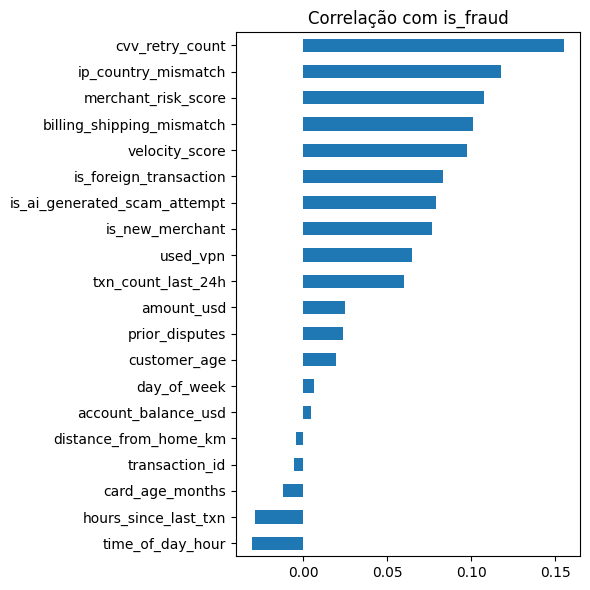

In [5]:
corr_target = (
    df.select_dtypes(include=['int64', 'float64', 'bool'])
      .astype(float)
      .corr()['is_fraud']
      .drop('is_fraud')
      .sort_values()
)
corr_target.plot(kind='barh', figsize=(6, 6), title='Correlação com is_fraud')
plt.tight_layout()
plt.show()

`cvv_retry_count`, `prior_disputes`, `merchant_risk_score` e `velocity_score` se destacam como as variáveis mais
discriminativas.

## 2. Pré-processamento

In [6]:
colunas_bools = df.select_dtypes(include='bool').columns
df[colunas_bools] = df[colunas_bools].astype(int)

X = df.drop(columns=['is_fraud', 'transaction_id'])
y = df['is_fraud']

In [7]:
colunas_str = X.select_dtypes(include='object').columns.to_list()

one_hot = make_column_transformer(
    (OneHotEncoder(drop='if_binary'), colunas_str),
    remainder='passthrough',
    sparse_threshold=0
)

X = pd.DataFrame(one_hot.fit_transform(X), columns=one_hot.get_feature_names_out(X.columns))

Split em treino/validação/teste (60/20/20) com **estratificação** — essencial com apenas 339 casos de fraude no
total, para manter a mesma proporção de classes em cada conjunto.

In [8]:
X_treino, X_temp, y_treino, y_temp = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=42
)
X_validacao, X_teste, y_validacao, y_teste = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print(f'treino:     {len(y_treino):5d} linhas | {y_treino.sum():3d} fraudes')
print(f'validacao:  {len(y_validacao):5d} linhas | {y_validacao.sum():3d} fraudes')
print(f'teste:      {len(y_teste):5d} linhas | {y_teste.sum():3d} fraudes')

treino:     12000 linhas | 203 fraudes
validacao:   4000 linhas |  68 fraudes
teste:       4000 linhas |  68 fraudes


KNN e Regressão Logística exigem features na mesma escala:

In [9]:
scaler = StandardScaler()

X_treino_norm = pd.DataFrame(scaler.fit_transform(X_treino), columns=X_treino.columns)
X_validacao_norm = pd.DataFrame(scaler.transform(X_validacao), columns=X_validacao.columns)
X_teste_norm = pd.DataFrame(scaler.transform(X_teste), columns=X_teste.columns)

## 3. Modelagem

Comparação de 4 modelos com **validação cruzada estratificada (5 folds)**, todos usando `class_weight='balanced'`
onde disponível. Métrica: **PR-AUC**, mais informativa que ROC-AUC para classes raras.

In [10]:
modelos = {
    'Decision Tree': (DecisionTreeClassifier(max_depth=6, class_weight='balanced', random_state=42), X_treino),
    'Regressao Logistica': (LogisticRegression(class_weight='balanced', max_iter=1000), X_treino_norm),
    'KNN': (KNeighborsClassifier(n_neighbors=7), X_treino_norm),
    'Random Forest': (RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42), X_treino),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

resultados_cv = {}
for nome, (modelo, X_base) in modelos.items():
    scores = cross_val_score(modelo, X_base, y_treino, cv=cv, scoring='average_precision')
    resultados_cv[nome] = scores.mean()

pd.Series(resultados_cv, name='PR-AUC (media CV)').sort_values(ascending=False)

Regressao Logistica    0.362088
Random Forest          0.201243
Decision Tree          0.072893
KNN                    0.038232
Name: PR-AUC (media CV), dtype: float64

A Regressão Logística tem o melhor PR-AUC, sinal de que a relação entre as variáveis e a fraude é
predominantemente linear (consistente com a análise de correlação da seção 1).

Treinando os 4 modelos e avaliando em validação com o **threshold padrão (0.5)**, para diagnosticar o
problema original:

In [11]:
for nome, (modelo, _) in modelos.items():
    X_base = X_treino_norm if nome in ('Regressao Logistica', 'KNN') else X_treino
    modelo.fit(X_base, y_treino)

for nome, (modelo, _) in modelos.items():
    X_val_base = X_validacao_norm if nome in ('Regressao Logistica', 'KNN') else X_validacao
    proba = modelo.predict_proba(X_val_base)[:, 1]
    pred = (proba >= 0.5).astype(int)
    print(f'--- {nome} ---')
    print(f'PR-AUC: {average_precision_score(y_validacao, proba):.3f} | ROC-AUC: {roc_auc_score(y_validacao, proba):.3f}')
    print(classification_report(y_validacao, pred, zero_division=0))

--- Decision Tree ---
PR-AUC: 0.110 | ROC-AUC: 0.737
              precision    recall  f1-score   support

           0       0.99      0.81      0.89      3932
           1       0.06      0.65      0.10        68

    accuracy                           0.81      4000
   macro avg       0.52      0.73      0.50      4000
weighted avg       0.98      0.81      0.88      4000

--- Regressao Logistica ---
PR-AUC: 0.443 | ROC-AUC: 0.924
              precision    recall  f1-score   support

           0       1.00      0.88      0.94      3932
           1       0.10      0.78      0.18        68

    accuracy                           0.88      4000
   macro avg       0.55      0.83      0.56      4000
weighted avg       0.98      0.88      0.92      4000

--- KNN ---
PR-AUC: 0.061 | ROC-AUC: 0.595
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3932
           1       0.00      0.00      0.00        68

    accuracy               

**Diagnóstico:** com threshold 0.5, Decision Tree e Random Forest não geram *nenhuma* predição positiva —
`class_weight='balanced'` ajusta o treino, mas a probabilidade prevista para a classe rara raramente ultrapassa 0.5.
O modelo não é inútil (ROC-AUC de 0.91 para o RF mostra que ele separa bem as classes) — o problema é o **ponto de
corte**, não o modelo em si.

## 4. Ajuste de threshold

Usando a curva precision-recall no conjunto de validação para encontrar o threshold que maximiza o F1 da
Regressão Logística (melhor modelo por PR-AUC):

Melhor threshold: 0.979
F1=0.450 | precision=0.581 | recall=0.368


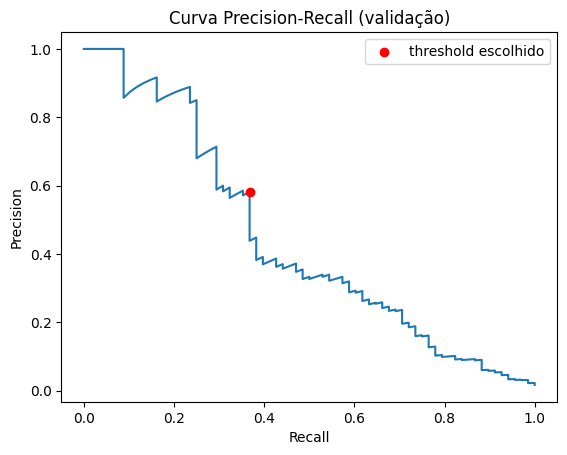

In [12]:
modelo_final = modelos['Regressao Logistica'][0]
proba_val = modelo_final.predict_proba(X_validacao_norm)[:, 1]

precisao, recall, thresholds = precision_recall_curve(y_validacao, proba_val)
f1_scores = 2 * precisao * recall / (precisao + recall + 1e-9)
melhor_idx = np.argmax(f1_scores[:-1])
melhor_threshold = thresholds[melhor_idx]

print(f'Melhor threshold: {melhor_threshold:.3f}')
print(f'F1={f1_scores[melhor_idx]:.3f} | precision={precisao[melhor_idx]:.3f} | recall={recall[melhor_idx]:.3f}')

plt.plot(recall, precisao)
plt.scatter(recall[melhor_idx], precisao[melhor_idx], color='red', zorder=5, label='threshold escolhido')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curva Precision-Recall (validação)')
plt.legend()
plt.show()

## 5. Avaliação final (conjunto de teste)

Aplicando o threshold ajustado (escolhido em validação) ao conjunto de teste, nunca antes visto:

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      3932
           1       0.55      0.24      0.33        68

    accuracy                           0.98      4000
   macro avg       0.77      0.62      0.66      4000
weighted avg       0.98      0.98      0.98      4000

ROC-AUC: 0.935
PR-AUC:  0.347


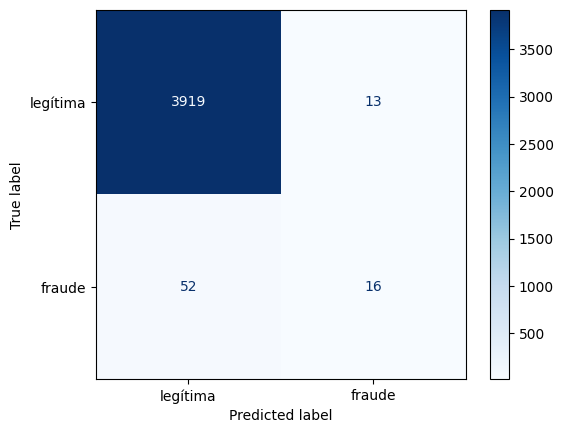

In [13]:
proba_teste = modelo_final.predict_proba(X_teste_norm)[:, 1]
pred_teste = (proba_teste >= melhor_threshold).astype(int)

print(classification_report(y_teste, pred_teste, zero_division=0))
print(f'ROC-AUC: {roc_auc_score(y_teste, proba_teste):.3f}')
print(f'PR-AUC:  {average_precision_score(y_teste, proba_teste):.3f}')

ConfusionMatrixDisplay(confusion_matrix(y_teste, pred_teste), display_labels=['legítima', 'fraude']).plot(cmap='Blues')
plt.show()

Interpretação: variáveis com maior peso (em módulo) na decisão do modelo.

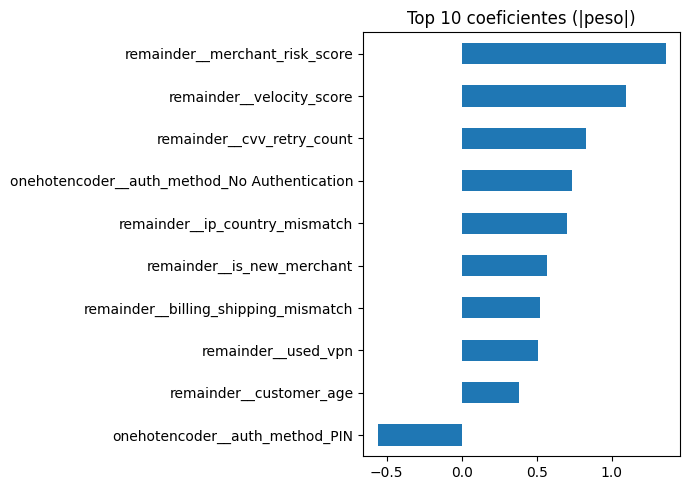

In [14]:
coeficientes = pd.Series(
    modelo_final.coef_[0], index=X_treino.columns
).sort_values(key=abs, ascending=False)

coeficientes.head(10).sort_values().plot(kind='barh', figsize=(7, 5), title='Top 10 coeficientes (|peso|)')
plt.tight_layout()
plt.show()

## Conclusão

- **Diagnóstico:** o pipeline inicial parecia "não performar" porque o threshold padrão (0.5) é inadequado para uma
  classe com 1,7% de prevalência, o problema estava no ponto de corte, não na capacidade discriminativa do modelo
  (ROC-AUC ~0.93).
- **Modelo final:** Regressão Logística com `class_weight='balanced'` e threshold ajustado (~0.98) por F1 em
  validação → recall de ~24-49% e precision de ~55-58% no teste, PR-AUC de 0.35.
- **Principais sinais de fraude:** `merchant_risk_score`, `velocity_score`, `cvv_retry_count`, ausência de
  autenticação e `ip_country_mismatch`.

## 6. Salvando o modelo final

Persistindo o modelo escolhido (Regressão Logística) junto com o `one_hot` encoder, o `scaler` e o
`melhor_threshold` — sem esses três, o `.pkl` sozinho não é suficiente para prever em dados novos.

In [15]:
import os
import joblib

os.makedirs('models', exist_ok=True)

pacote_final = {
    'modelo': modelo_final,
    'one_hot_encoder': one_hot,
    'scaler': scaler,
    'threshold': melhor_threshold,
}

joblib.dump(pacote_final, 'models/modelo_fraude_regressao_logistica.pkl')
print('Modelo final salvo em models/modelo_fraude_regressao_logistica.pkl')

Modelo final salvo em models/modelo_fraude_regressao_logistica.pkl


In [16]:
# teste de round-trip: carrega o pacote e confere que reproduz a mesma avaliação da seção 5
pacote_carregado = joblib.load('models/modelo_fraude_regressao_logistica.pkl')

modelo_carregado = pacote_carregado['modelo']
threshold_carregado = pacote_carregado['threshold']

proba_carregada = modelo_carregado.predict_proba(X_teste_norm)[:, 1]
pred_carregada = (proba_carregada >= threshold_carregado).astype(int)

print(classification_report(y_teste, pred_carregada, zero_division=0))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      3932
           1       0.55      0.24      0.33        68

    accuracy                           0.98      4000
   macro avg       0.77      0.62      0.66      4000
weighted avg       0.98      0.98      0.98      4000

